# Examen Enero 2024 (Aprendizaje Automático y Minería de Datos) — Solución guía

**Nombre:** _TU NOMBRE AQUÍ_

Este notebook está pensado como **apuntes reutilizables**: carga el dataset, lo limpia con criterios claros, representa los datos y entrena dos modelos (MLP propio y Decision Tree), siguiendo los ejercicios del examen.

> Nota: el enunciado original del examen está en el PDF `ExamenEnero2024.pdf`.


## 0) Imports y carga de datos
Coloca `dementia_dataset.csv` en la misma carpeta que este notebook (o ajusta la ruta).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

pd.set_option('display.max_columns', 200)


In [2]:
# Ruta relativa por defecto (recomendable para entregar zips)
DATA_PATH = "dementia_dataset.csv"

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (373, 15)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


### Vista rápida y nulos

In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), object(5)
memory usage: 43.8+ KB


In [4]:
df_raw.isna().sum()


Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64

## Ejercicio 1 (1 punto): Limpieza del dataset
Objetivo: eliminar columnas irrelevantes/erróneas y dejar el dataset listo para entrenar.

### Decisiones de limpieza (justificación)
- **Eliminar `Subject ID` y `MRI ID`**: son identificadores. No representan una prueba médica y pueden introducir **fugas de información** (el modelo puede memorizar IDs o patrones de visitas).
- **Eliminar `Hand`**: en este dataset aparece constante (solo `R`), por lo que **no aporta información**.
- **Tratar nulos en `SES` y `MMSE`**: en vez de borrar filas “a lo loco”, imputamos con **mediana** en variables numéricas. Es una opción estable (robusta a outliers) y suele rendir bien en exámenes.
- **Codificar `M/F`**: es categórica, así que la pasaremos a one-hot en el pipeline.

> Consejo de examen: en la justificación, menciona siempre **fuga de información**, **constantes**, y por qué eliges imputar (mediana) vs. borrar filas (pérdida de datos).


In [5]:
df = df_raw.copy()

# 1) Quitamos IDs y columnas constantes/irrelevantes
cols_to_drop = ["Subject ID", "MRI ID", "Hand"]
df = df.drop(columns=cols_to_drop)

# 2) (Opcional) comprobación rápida de constantes
for c in df.columns:
    if df[c].nunique(dropna=False) == 1:
        print("Columna constante:", c, "->", df[c].unique())

df.head()


,Group,Visit,MR Delay,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,Nondemented,1,0,M,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,Nondemented,2,457,M,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,Demented,1,0,M,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,Demented,2,560,M,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,Demented,3,1895,M,80,12,NaN,22.0,0.5,1698,0.701,1.034


### Separación X/y (antes del pipeline)
Dejamos el target `Group` aparte. Lo demás son features.


In [6]:
X = df.drop(columns=["Group"])
y = df["Group"]

print("X shape:", X.shape)
print("y counts:\n", y.value_counts())


X shape: (373, 11)
y counts:
 Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64


## Ejercicio 2 (1 punto): Representación gráfica
Gráficas típicas de examen:
- Distribución de clases
- Histograma de edades por grupo
- Boxplot de MMSE por grupo (muy informativo)
- Matriz de correlación (solo numéricas)


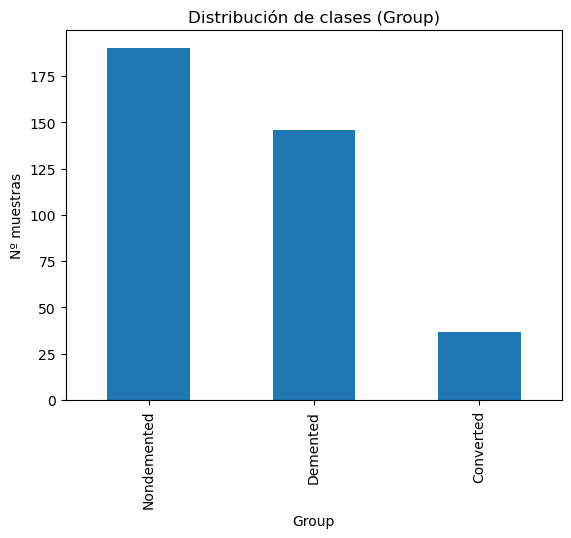

In [7]:
# 1) Distribución de clases
plt.figure()
y.value_counts().plot(kind="bar")
plt.title("Distribución de clases (Group)")
plt.xlabel("Group")
plt.ylabel("Nº muestras")
plt.show()


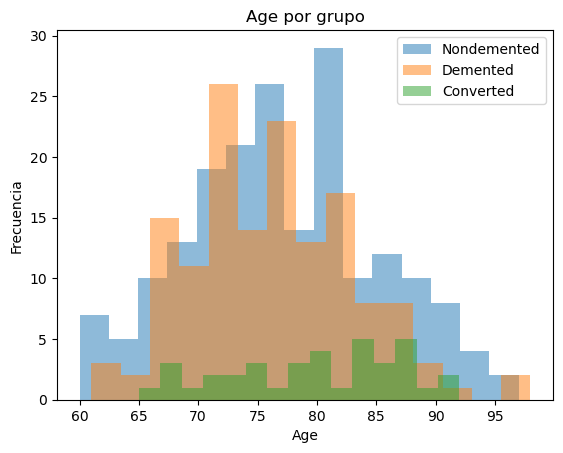

In [8]:
# 2) Histograma de Age por grupo
plt.figure()
for g in y.unique():
    X.loc[y==g, "Age"].plot(kind="hist", alpha=0.5, bins=15, label=g)
plt.title("Age por grupo")
plt.xlabel("Age")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


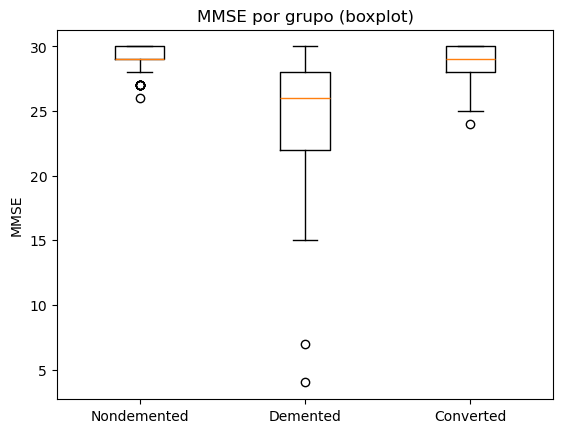

In [9]:
# 3) Boxplot de MMSE por grupo (si existe)
if "MMSE" in X.columns:
    plt.figure()
    data = [X.loc[y==g, "MMSE"].dropna() for g in y.unique()]
    plt.boxplot(data, tick_labels=list(y.unique()))
    plt.title("MMSE por grupo (boxplot)")
    plt.ylabel("MMSE")
    plt.show()


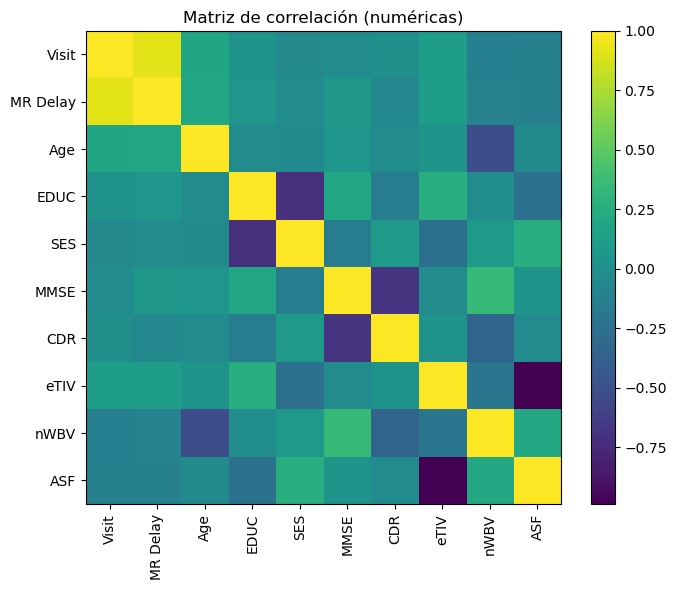

In [10]:
# 4) Correlación (solo numéricas)
num_cols = X.select_dtypes(include=[np.number]).columns
corr = X[num_cols].corr()

plt.figure(figsize=(7, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Matriz de correlación (numéricas)")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.tight_layout()
plt.show()


## Ejercicio 3 (2 puntos): Perceptrón Multicapa (MLP) propio
Implementación **en NumPy** de un MLP con backprop.

Requisitos del examen:
- Conseguir al menos **65% accuracy**.
- Probar al menos un modelo con **más de una capa oculta** (aunque luego el definitivo sea otro).

### Preprocesado
- Numéricas: imputación (mediana) + estandarización.
- Categóricas: one-hot.
- Target `Group`: label encoding (0..C-1).


In [11]:
# Columnas categóricas y numéricas
cat_cols = ["M/F"]
num_cols = [c for c in X.columns if c not in cat_cols]

pre_mlp = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_t = pre_mlp.fit_transform(X_train)
X_test_t  = pre_mlp.transform(X_test)

le = LabelEncoder()
y_train_i = le.fit_transform(y_train)
y_test_i  = le.transform(y_test)

n_classes = len(le.classes_)
print("X_train_t shape:", X_train_t.shape)
print("Clases:", le.classes_)


X_train_t shape: (298, 12)
Clases: ['Converted' 'Demented' 'Nondemented']


In [12]:
def one_hot(y_int, num_classes):
    oh = np.zeros((y_int.size, num_classes), dtype=np.float32)
    oh[np.arange(y_int.size), y_int] = 1.0
    return oh

class NumpyMLP:
    """MLP multicapa en NumPy para clasificación multiclase (softmax + cross-entropy)."""
    def __init__(self, layer_sizes, activation="relu", seed=1, l2=1e-4):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.rng = np.random.default_rng(seed)
        self.l2 = float(l2)

        self.W = []
        self.b = []
        for i in range(len(layer_sizes)-1):
            fan_in  = layer_sizes[i]
            fan_out = layer_sizes[i+1]

            # Inicialización (He para ReLU, Xavier aprox. para otras)
            if i < len(layer_sizes)-2 and activation == "relu":
                scale = np.sqrt(2.0 / fan_in)
            else:
                scale = np.sqrt(1.0 / fan_in)

            self.W.append(self.rng.normal(0, scale, size=(fan_in, fan_out)).astype(np.float32))
            self.b.append(np.zeros((1, fan_out), dtype=np.float32))

    def _act(self, z):
        if self.activation == "relu":
            return np.maximum(0, z)
        if self.activation == "tanh":
            return np.tanh(z)
        if self.activation == "sigmoid":
            return 1/(1+np.exp(-z))
        raise ValueError("Activation no soportada")

    def _act_deriv(self, z, a):
        if self.activation == "relu":
            return (z > 0).astype(np.float32)
        if self.activation == "tanh":
            return 1 - a*a
        if self.activation == "sigmoid":
            return a*(1-a)
        raise ValueError("Activation no soportada")

    def _softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        exp = np.exp(z)
        return exp / np.sum(exp, axis=1, keepdims=True)

    def forward(self, X):
        a = X.astype(np.float32)
        activations = [a]
        zs = []
        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            zs.append(z)
            if i == len(self.W)-1:
                a = self._softmax(z)
            else:
                a = self._act(z)
            activations.append(a)
        return activations, zs

    def predict(self, X):
        a = X.astype(np.float32)
        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            if i == len(self.W)-1:
                a = self._softmax(z)
            else:
                a = self._act(z)
        return np.argmax(a, axis=1)

    def fit(self, X, y_int, epochs=400, lr=0.05, batch_size=32, verbose=False):
        X = X.astype(np.float32)
        y_oh = one_hot(y_int, self.layer_sizes[-1])
        n = X.shape[0]

        for ep in range(epochs):
            idx = self.rng.permutation(n)
            Xs = X[idx]
            ys = y_oh[idx]

            for start in range(0, n, batch_size):
                xb = Xs[start:start+batch_size]
                yb = ys[start:start+batch_size]

                activations, zs = self.forward(xb)

                # Gradiente de softmax + cross-entropy
                delta = (activations[-1] - yb) / xb.shape[0]

                dW = []
                db = []
                for i in reversed(range(len(self.W))):
                    a_prev = activations[i]
                    dWi = a_prev.T @ delta + self.l2 * self.W[i]
                    dbi = np.sum(delta, axis=0, keepdims=True)
                    dW.append(dWi)
                    db.append(dbi)

                    if i > 0:
                        z_prev = zs[i-1]
                        a_prev_act = activations[i]
                        delta = (delta @ self.W[i].T) * self._act_deriv(z_prev, a_prev_act)

                dW = dW[::-1]
                db = db[::-1]

                for i in range(len(self.W)):
                    self.W[i] -= lr * dW[i]
                    self.b[i] -= lr * db[i]

            if verbose and (ep % 50 == 0 or ep == epochs-1):
                acc = (self.predict(X) == y_int).mean()
                print(f"Epoch {ep:4d} | train acc = {acc:.3f}")

        return self


### Entrenamiento (prueba con >1 capa oculta)
Aquí cumplimos el requisito de probar un MLP con dos capas ocultas.


Accuracy (MLP 2 hidden layers): 0.8666666666666667


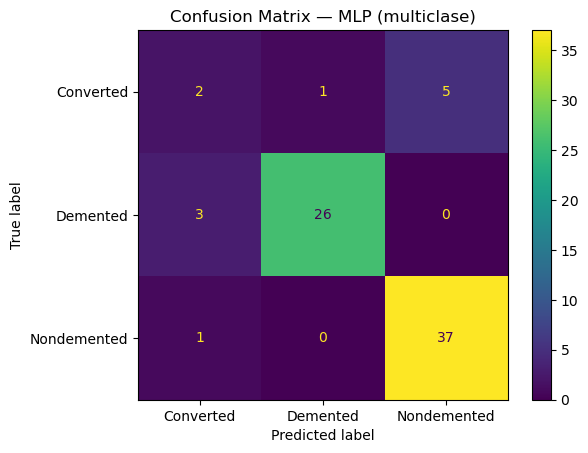

In [13]:
mlp_deep = NumpyMLP(
    layer_sizes=[X_train_t.shape[1], 16, 8, n_classes],
    activation="relu",
    seed=1,
    l2=1e-4
)
mlp_deep.fit(X_train_t, y_train_i, epochs=400, lr=0.05, batch_size=32, verbose=False)

pred = mlp_deep.predict(X_test_t)
acc = accuracy_score(y_test_i, pred)
print("Accuracy (MLP 2 hidden layers):", acc)

cm = confusion_matrix(y_test_i, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(values_format="d")
plt.title("Confusion Matrix — MLP (multiclase)")
plt.show()


### Entrenamiento (modelo alternativo: 1 capa oculta)
En exámenes suele venir bien probar 1 capa oculta como comparación rápida.


Accuracy (MLP 1 hidden layer): 0.8933333333333333


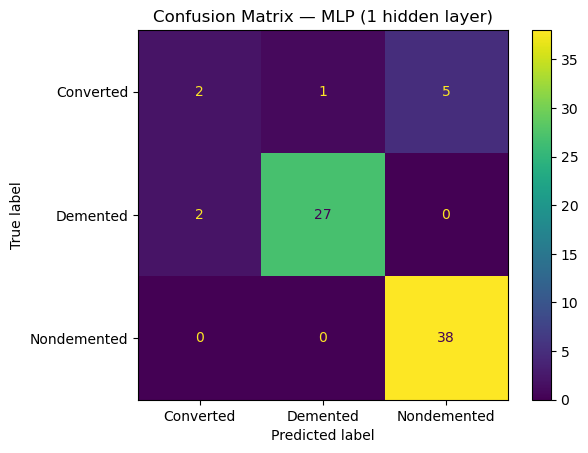

Modelo final recomendado (aquí): mlp_shallow


In [14]:
mlp_shallow = NumpyMLP(
    layer_sizes=[X_train_t.shape[1], 12, n_classes],
    activation="relu",
    seed=2,
    l2=1e-4
)
mlp_shallow.fit(X_train_t, y_train_i, epochs=400, lr=0.05, batch_size=32, verbose=False)

pred2 = mlp_shallow.predict(X_test_t)
acc2 = accuracy_score(y_test_i, pred2)
print("Accuracy (MLP 1 hidden layer):", acc2)

cm2 = confusion_matrix(y_test_i, pred2)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=le.classes_)
disp2.plot(values_format="d")
plt.title("Confusion Matrix — MLP (1 hidden layer)")
plt.show()

print("Modelo final recomendado (aquí):", "mlp_deep" if acc >= acc2 else "mlp_shallow")


## Ejercicio 4 (1.5 puntos): Decision Tree (sklearn)
Requisito: **accuracy ≥ 85%** con `random_state=42`.

Los árboles no necesitan escalado, pero sí que conviene imputar nulos y one-hot para categorías.


Accuracy (Decision Tree): 0.8533333333333334


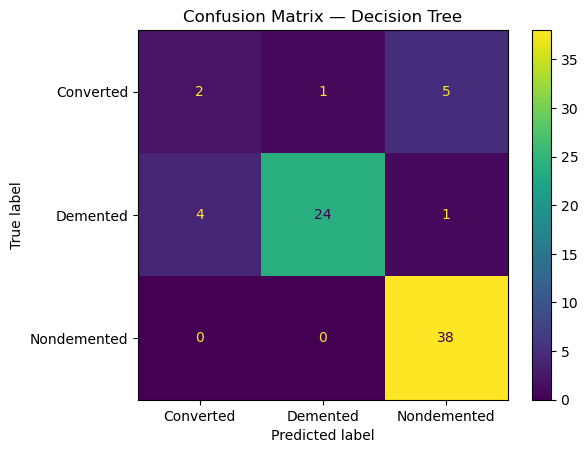

In [15]:
pre_dt = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

dt = DecisionTreeClassifier(random_state=42)

pipe_dt = Pipeline([
    ("pre", pre_dt),
    ("model", dt)
])

pipe_dt.fit(X_train, y_train)
pred_dt = pipe_dt.predict(X_test)

acc_dt = accuracy_score(y_test, pred_dt)
print("Accuracy (Decision Tree):", acc_dt)

cm_dt = confusion_matrix(y_test, pred_dt, labels=le.classes_)
disp_dt = ConfusionMatrixDisplay(cm_dt, display_labels=le.classes_)
disp_dt.plot(values_format="d")
plt.title("Confusion Matrix — Decision Tree")
plt.show()


## Ejercicio 5 (1 punto): Comparación de modelos (markdown)
Puntos que puedes comentar:
- **Árbol de decisión**: suele rendir muy bien en datasets tabulares pequeños, maneja relaciones no lineales y splits por umbral. Riesgo: sobreajuste si no se limita `max_depth`/`min_samples_leaf`.
- **MLP**: necesita más cuidado con escalado, learning rate, arquitectura… pero puede generalizar bien y capturar combinaciones complejas.
- En este dataset, ambos pueden rendir bien. Si el árbol alcanza fácilmente ≥85% y el objetivo es identificar Converted, podrías preferir el árbol por simplicidad e interpretabilidad. Si tu MLP iguala/supera y quieres un modelo más flexible, eliges MLP.

**Ejemplo de conclusión:**
> Me quedo con el Decision Tree porque alcanza el umbral del examen con menor ajuste de hiperparámetros y ofrece interpretabilidad, lo que es valioso en un contexto médico. Aun así, el MLP es competitivo si se escala e imputa correctamente.


## Ejercicio 6 (1.5 puntos): Binaria (Converted → Demented) con 1 neurona de salida
Creamos una etiqueta binaria:
- 1: Demented (incluye Converted)
- 0: Nondemented

y entrenamos un MLP con **una única neurona de salida** (sigmoid + binary cross-entropy).


In [16]:
df_bin = df.copy()
df_bin["Group_bin"] = df_bin["Group"].replace({"Converted": "Demented"})

Xb = df_bin.drop(columns=["Group", "Group_bin"])
yb = (df_bin["Group_bin"] == "Demented").astype(int)  # 1=demented, 0=nondemented

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.2, random_state=42, stratify=yb
)

cat_cols_b = ["M/F"]
num_cols_b = [c for c in Xb.columns if c not in cat_cols_b]

pre_bin = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols_b),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols_b),
])

Xb_train_t = pre_bin.fit_transform(Xb_train)
Xb_test_t  = pre_bin.transform(Xb_test)

print("Xb_train_t shape:", Xb_train_t.shape, " | Positivos:", yb_train.mean())


Xb_train_t shape: (298, 12)  | Positivos: 0.4899328859060403


In [17]:
class NumpyMLPBinary(NumpyMLP):
    """MLP binario (sigmoid + binary cross-entropy) con 1 neurona de salida."""
    def forward(self, X):
        a = X.astype(np.float32)
        activations = [a]
        zs = []
        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            zs.append(z)
            if i == len(self.W)-1:
                a = 1/(1+np.exp(-z))  # sigmoid
            else:
                a = self._act(z)
            activations.append(a)
        return activations, zs

    def predict_proba(self, X):
        a = X.astype(np.float32)
        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            if i == len(self.W)-1:
                a = 1/(1+np.exp(-z))
            else:
                a = self._act(z)
        return a

    def predict(self, X, thresh=0.5):
        p = self.predict_proba(X).ravel()
        return (p >= thresh).astype(int)

    def fit(self, X, y, epochs=400, lr=0.05, batch_size=32, verbose=False):
        X = X.astype(np.float32)
        y = y.astype(np.float32).reshape(-1, 1)
        n = X.shape[0]

        for ep in range(epochs):
            idx = self.rng.permutation(n)
            Xs = X[idx]
            ys = y[idx]

            for start in range(0, n, batch_size):
                xb = Xs[start:start+batch_size]
                yb = ys[start:start+batch_size]

                activations, zs = self.forward(xb)
                out = activations[-1]

                # Derivada BCE+sigmoid: (out - y)/m
                delta = (out - yb) / xb.shape[0]

                dW = []
                db = []
                for i in reversed(range(len(self.W))):
                    a_prev = activations[i]
                    dWi = a_prev.T @ delta + self.l2 * self.W[i]
                    dbi = np.sum(delta, axis=0, keepdims=True)
                    dW.append(dWi)
                    db.append(dbi)

                    if i > 0:
                        z_prev = zs[i-1]
                        a_prev_act = activations[i]
                        delta = (delta @ self.W[i].T) * self._act_deriv(z_prev, a_prev_act)

                dW = dW[::-1]
                db = db[::-1]
                for i in range(len(self.W)):
                    self.W[i] -= lr * dW[i]
                    self.b[i] -= lr * db[i]

            if verbose and (ep % 50 == 0 or ep == epochs-1):
                acc = (self.predict(X) == y.ravel()).mean()
                print(f"Epoch {ep:4d} | train acc = {acc:.3f}")

        return self


Accuracy (MLP binario): 0.9333333333333333


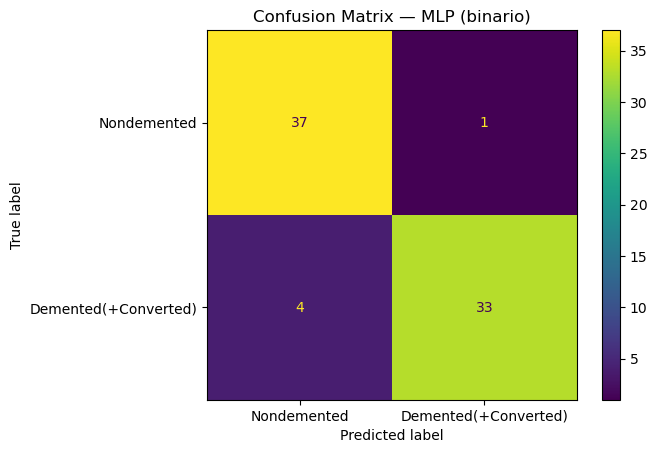

In [18]:
mlp_bin = NumpyMLPBinary(
    layer_sizes=[Xb_train_t.shape[1], 16, 8, 1],
    activation="relu",
    seed=3,
    l2=1e-4
)
mlp_bin.fit(Xb_train_t, yb_train.values, epochs=400, lr=0.05, batch_size=32, verbose=False)

pred_bin = mlp_bin.predict(Xb_test_t)
acc_bin = accuracy_score(yb_test, pred_bin)
print("Accuracy (MLP binario):", acc_bin)

cm_bin = confusion_matrix(yb_test, pred_bin, labels=[0, 1])
disp_bin = ConfusionMatrixDisplay(cm_bin, display_labels=["Nondemented", "Demented(+Converted)"])
disp_bin.plot(values_format="d")
plt.title("Confusion Matrix — MLP (binario)")
plt.show()


## Anexo: Tips rápidos de limpieza (para evitar penalizaciones)
- **Siempre** imprime `df.isna().sum()`.
- Si hay pocas filas con NaN, puedes justificar `dropna()`. Si hay más, suele ser mejor imputar.
- Busca columnas **constantes** (`nunique()==1`) y **IDs**: casi siempre se eliminan.
- Explica por qué: *no aportan señal*, *introducen ruido*, o *fuga de información*.
- En tabular: one-hot para categóricas + imputación mediana para numéricas suele funcionar bien.

---
Fin de la guía.
